In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
import os
os.getcwd()

'/Users/jessie/Desktop/berk/summer 26/207/watts-the-cost-DATASCI-207'

In [8]:
df = pd.read_parquet('data/cleaned_data.parquet')

In [12]:
df.shape

(62448, 43)

In [13]:
df.columns

Index(['zip', 'households', 'moe_households', 'households_less_than_$10k',
       'moe_households_less_than_$10k', 'households_$10k_to_$14k',
       'moe_households_$10k_to_$14k', 'households_$15k_to_$24k',
       'moe_households_$15k_to_$24k', 'households_$25k_to_$34k',
       'moe_households_$25k_to_$34k', 'households_$35k_to_$49k',
       'moe_households_$35k_to_$49k', 'households_$50k_to_$74k',
       'moe_households_$50k_to_$74k', 'households_$75k_to_$99k',
       'moe_households_$75k_to_$99k', 'households_$100k_to_$149k',
       'moe_households_$100k_to_$149k', 'households_$150k_to_$199k',
       'moe_households_$150k_to_$199k', 'households_$200k_or_more',
       'moe_households_$200k_or_more', 'households_median_income',
       'moe_households_median_income', 'households_mean_income',
       'moe_households_mean_income',
       'households_percent_allocated_household_income_in_the_past_12_months',
       'est', 'n<5', 'n5_9', 'n10_19', 'n20_49', 'n50_99', 'n100_249',
       'n25

### looking at state level data

In [46]:
import pgeocode

nomi = pgeocode.Nominatim('us')

# 1. clean ZIPs
zip_list = df['zip'].astype(str).str.zfill(5).unique()

# 2. lookup ONLY unique ZIPs
lookup = nomi.query_postal_code(zip_list)

# 3. build mapping
zip_to_state = dict(zip(zip_list, lookup['state_code']))

# 4. map back
df['state'] = df['zip'].astype(str).str.zfill(5).map(zip_to_state)

In [53]:
state_rates = df.groupby('state')[['res_rate', 'comm_rate', 'ind_rate']].mean().reset_index()

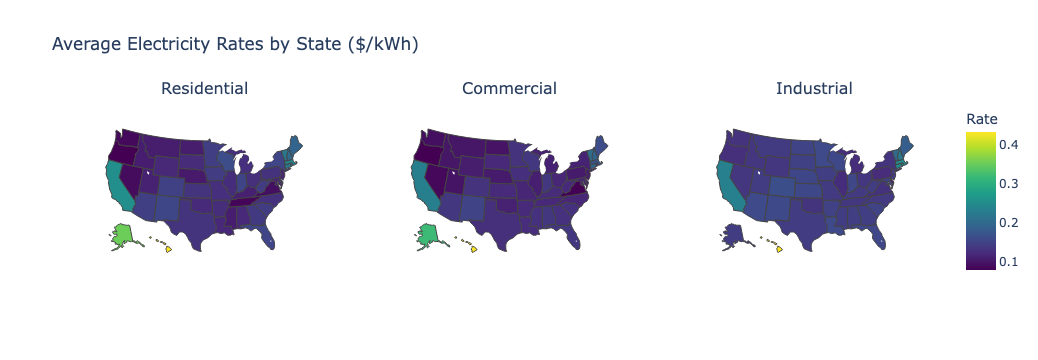

In [76]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=["Residential", "Commercial", "Industrial"],
    specs=[[{"type": "choropleth"}] * 3]
)

for col, (rate_col, title) in enumerate([
    ('res_rate', 'Residential'),
    ('comm_rate', 'Commercial'),
    ('ind_rate', 'Industrial')
], start=1):
    fig.add_trace(
        go.Choropleth(
            locations=state_rates['state'],
            z=state_rates[rate_col],
            locationmode="USA-states",
            colorscale="Viridis",
            colorbar_title="Rate",
            name=title,
            showscale=(col == 1) 
        ),
        row=1, col=col
    )
    fig.update_geos(scope="usa", row=1, col=col)

fig.update_layout(
    title_text="Average Electricity Rates by State ($/kWh)"
)

fig.show()

We notice that California and Hawaii have the highest rates across residential, commercial, and industrial rates. Alaska has high residential and commercial rates, but lower industrial rates. Industrial rates are slightly higher across the central US.

### Pivoting the table so rates is one col

In [73]:
rate_cols = ['comm_rate', 'ind_rate', 'res_rate']
id_cols = [c for c in df.columns if c not in rate_cols]

df_long = df.melt(
    id_vars=id_cols,
    value_vars=rate_cols,
    var_name='rate_type',
    value_name='rate'
)

df_long['rate_type'] = df_long['rate_type'].str.replace('_rate', '')

In [79]:
df_long.to_parquet('data/cleaned_data_long.parquet', index=False)